In [ ]:
import os
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd

# initialize MediaPipe Hands
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=True, 
    max_num_hands=1, 
    min_detection_confidence=0.5
)


DATASET_DIR = "Gesture Image Data/Gesture Image Data"    
data = []
labels = []

print("[INFO] Starting landmark extraction using (x, y) coordinates...")

for label in os.listdir(DATASET_DIR):
    class_dir = os.path.join(DATASET_DIR, label)
    if not os.path.isdir(class_dir):
        continue
    
    print(f"[INFO] Processing class: {label}")
    for img_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_name)
        image = cv2.imread(img_path)
        if image is None:
            continue
            
        # convert to RGB
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        results = hands.process(image_rgb)
        
        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                # extract x and y coordinates only (21 points * 2 = 42 values)
                landmarks = []
                for lm in hand_landmarks.landmark:
                    landmarks.append([lm.x, lm.y])
                
                landmarks = np.array(landmarks, dtype=np.float32)
                
                # --- Normalization (Translation & Scaling) ---
                # 1. Translation:   (Wrist - 0 point )   (0,0)
                wrist = landmarks[0]
                landmarks = landmarks - wrist
                
                # 2. Scale Normalization: 
                max_distance = np.max(np.sqrt(np.sum(landmarks**2, axis=1)))
                if max_distance != 0:
                    landmarks = landmarks / max_distance
                
                # convert the array to a flat array (Flat array of 42 features)
                flattened_features = landmarks.flatten().tolist()
                
                data.append(flattened_features)
                labels.append(label)

hands.close()

# create DataFrame and save it to a CSV file
columns = []
for i in range(21):
    columns.extend([f"x{i}", f"y{i}"])
columns.append("label")


dataset=[]
for features, label in zip(data, labels):
    dataset.append(features + [label])

df = pd.DataFrame(dataset, columns=columns)

df.to_csv("dataset.csv", index=False)
print(f"[SUCCESS] Extraction complete! Saved {len(df)} samples to dataset.csv")

[INFO] Starting landmark extraction using (x, y) coordinates...
[INFO] Processing class: 0


e:\computer_cv\venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


[INFO] Processing class: 1
[INFO] Processing class: 2
[INFO] Processing class: 3
[INFO] Processing class: 4
[INFO] Processing class: 5
[INFO] Processing class: 6
[INFO] Processing class: 7
[INFO] Processing class: 8
[INFO] Processing class: 9
[INFO] Processing class: A
[INFO] Processing class: B
[INFO] Processing class: C
[INFO] Processing class: D
[INFO] Processing class: E
[INFO] Processing class: F
[INFO] Processing class: G
[INFO] Processing class: H
[INFO] Processing class: I
[INFO] Processing class: J
[INFO] Processing class: K
[INFO] Processing class: L
[INFO] Processing class: M
[INFO] Processing class: N
[INFO] Processing class: O
[INFO] Processing class: P
[INFO] Processing class: Q
[INFO] Processing class: R
[INFO] Processing class: S
[INFO] Processing class: T
[INFO] Processing class: U
[INFO] Processing class: V
[INFO] Processing class: W
[INFO] Processing class: X
[INFO] Processing class: Y
[INFO] Processing class: Z
[SUCCESS] Extraction complete! Saved 2641 samples to da

In [6]:
!pip install jinja2


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report,f1_score
import joblib

print("[INFO] Loading dataset...")
df = pd.read_csv("dataset.csv")

df=df.dropna()

#  seperate Features about Labels
X = df.drop(columns=["label"])
y = df["label"]

#  split the dataset into training and testing sets (80% train, 20% test)  
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# initialize the models to be evaluated
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', C=10),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

training_times={}
comparsion_result=[]

best_model_name = ""
best_model = None
best_accuracy = 0.0

print("\n[INFO] Training and evaluating models...")

for name,model in models.items():

  start_time= time.time()
  model.fit(X_train,y_train)
  end_time=time.time()

  training_times[name]= end_time - start_time


  y_train_pred=model.predict(X_train)
  y_test_pred=model.predict(X_test)

  train_acc= accuracy_score(y_train, y_train_pred)
  test_acc= accuracy_score(y_test, y_test_pred)

  train_f1=f1_score(y_train,y_train_pred,average='macro')
  test_f1=f1_score(y_test,y_test_pred,average='macro')

  print(f"\n=================={name}=================")
  print(f"-> Train Accuracy : {train_acc * 100:.2f}%")
  print(f"-> Test Accuracy :{test_acc * 100:.2f}%")
 


  if train_acc - test_acc > 0.10:
     print(
        "[WARNING] Model might be suffering from Overfitting (High difference"
        " between train & test)."
    )
  else:
      print("[INFO] Generalization is good (No severe overfitting).")



  comparsion_result.append(
     
        {"Model": name, 
         "Train Accuracy":round(train_acc * 100,2) ,
           "Test Accuracy":round(test_acc * 100,2) ,
           "Train F1_Score":round(train_f1,4),
           "Test F1_Score":round(test_f1,4) ,
           "Time (s)":round(training_times[name],2)}
    )


  if test_acc > best_accuracy:
     best_accuracy = test_acc
     best_model = model
     best_model_name = name


comparison_df= pd.DataFrame(comparsion_result)

styled_df= comparison_df.style.highlight_max(
   
   

   subset=["Train Accuracy","Test Accuracy","Train F1_Score","Test F1_Score"],
   color='white',
).format({

"Train Accuracy": "{:.2f}%" ,
           "Test Accuracy": "{:.2f}% " ,
           "Train F1_Score": "{:.4f}",
           "Test F1_Score":"{:.4f}" ,
           "Time (s)": "{:.2f}s"
   
})



  # select best model based on Test Accuracy

# final table of comparison
print("\n" + "=" * 40)
print("          MODEL COMPARISON TABLE          ")
print("=" * 40)
comparison_df = pd.DataFrame(comparsion_result)
print(comparison_df.to_string(index=False))

print("=" * 40)

print(
    f"\n[WINNER] Best Model is '{best_model_name}' with Test Accuracy:"
    f" {best_accuracy * 100:.2f}%"
)

# save the best model to a file using joblib
model_filename = "best_sign_model.pkl"

joblib.dump(best_model, model_filename)
print(f"[SUCCESS] Best model successfully saved to {model_filename}")

display(styled_df)

[INFO] Loading dataset...

[INFO] Training and evaluating models...

==================Random Forest=================
-> Train Accuracy : 100.00%
-> Test Accuracy :95.65%
[INFO] Generalization is good (No severe overfitting).

==================SVM=================
-> Train Accuracy : 96.26%
-> Test Accuracy :96.03%
[INFO] Generalization is good (No severe overfitting).

==================K-Nearest Neighbors=================
-> Train Accuracy : 95.27%
-> Test Accuracy :92.82%
[INFO] Generalization is good (No severe overfitting).

          MODEL COMPARISON TABLE          
              Model  Train Accuracy  Test Accuracy  Train F1_Score  Test F1_Score  Time (s)
      Random Forest          100.00          95.65          1.0000         0.9500      1.47
                SVM           96.26          96.03          0.9570         0.9523      0.09
K-Nearest Neighbors           95.27          92.82          0.9449         0.9190      0.01

[WINNER] Best Model is 'SVM' with Test Accuracy: 96

,Model,Train Accuracy,Test Accuracy,Train F1_Score,Test F1_Score,Time (s)
0,Random Forest,100.00%,95.65%,1.0000,0.9500,1.47s
1,SVM,96.26%,96.03%,0.9570,0.9523,0.09s
2,K-Nearest Neighbors,95.27%,92.82%,0.9449,0.9190,0.01s


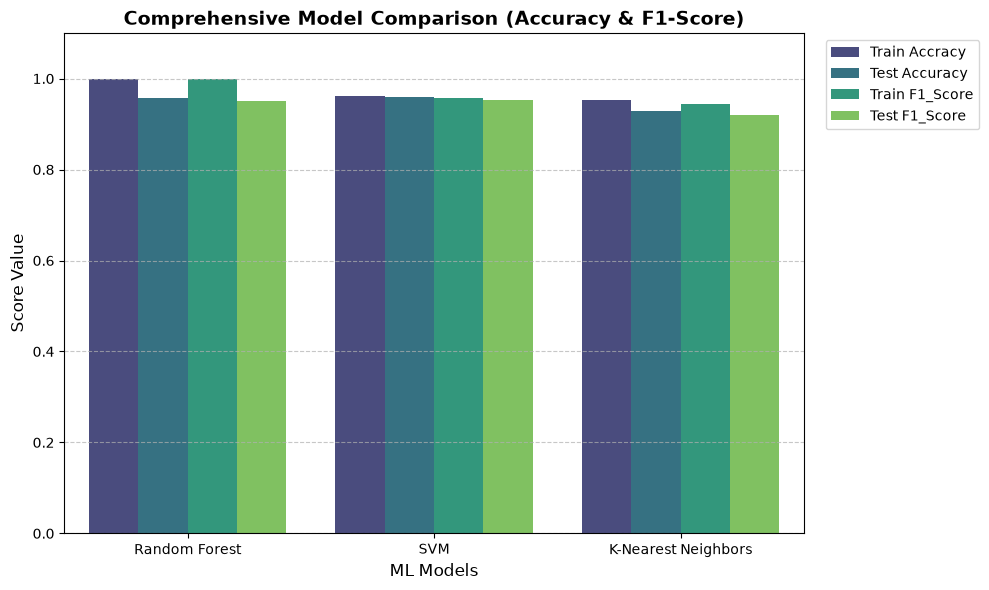

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#  prepare the data for visualization
df_melted = comparison_df.melt(id_vars="Model", 
                               var_name="Metric", 
                               value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Score", hue="Metric", data=df_melted, palette="viridis")


plt.title("Comprehensive Model Comparison (Accuracy & F1-Score)", fontsize=14, fontweight='bold')
plt.ylabel("Score Value", fontsize=12)
plt.xlabel("ML Models", fontsize=12)
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

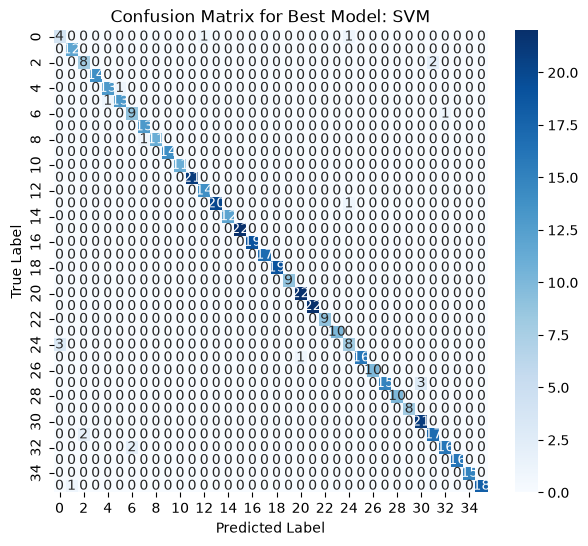

<Figure size 900x500 with 0 Axes>

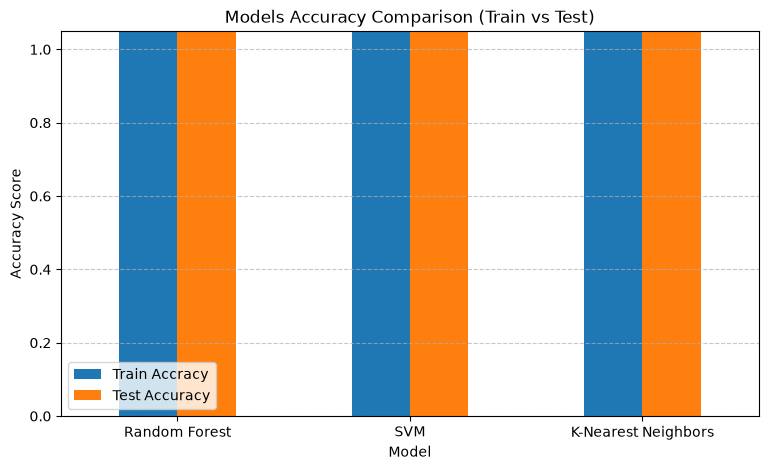

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. (Confusion Matrix) to best model
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')


plt.title(f"Confusion Matrix for Best Model: {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# 2. convert comparison results to DataFrame for easy plotting
comparison_df = pd.DataFrame(comparsion_result)

# plot accuracy comparison for each model
plt.figure(figsize=(9, 5))
comparison_df.set_index("Model")[["Train Accracy", "Test Accuracy"]].plot(kind='bar', figsize=(9, 5))
plt.title("Models Accuracy Comparison (Train vs Test)")
plt.ylabel("Accuracy Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

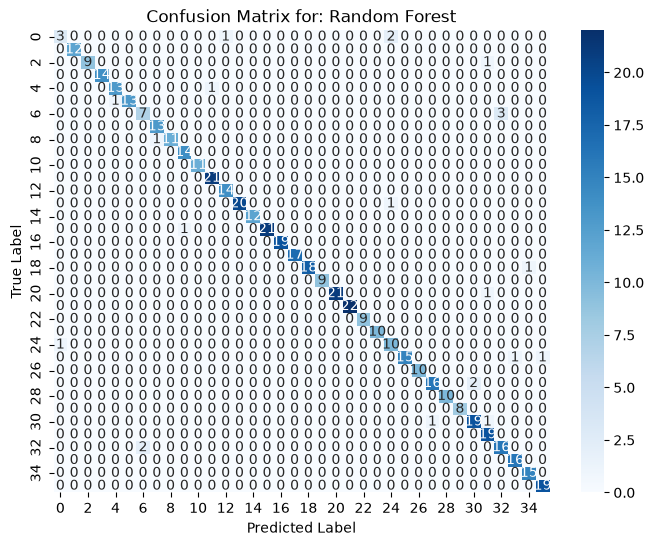

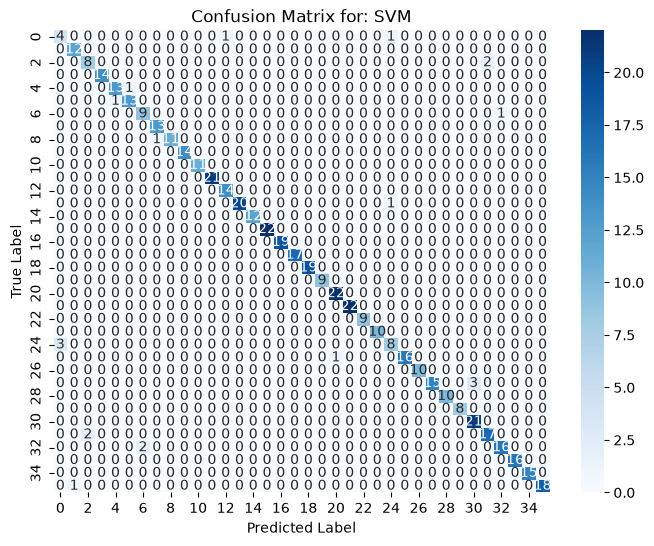

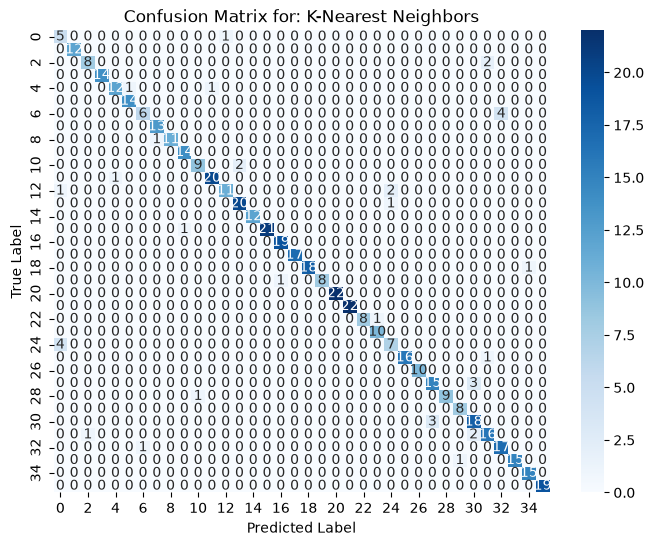

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in models.items():
    # predict the results for the current model
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    #  Confusion Matrix for each model
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    
    plt.title(f"Confusion Matrix for: {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

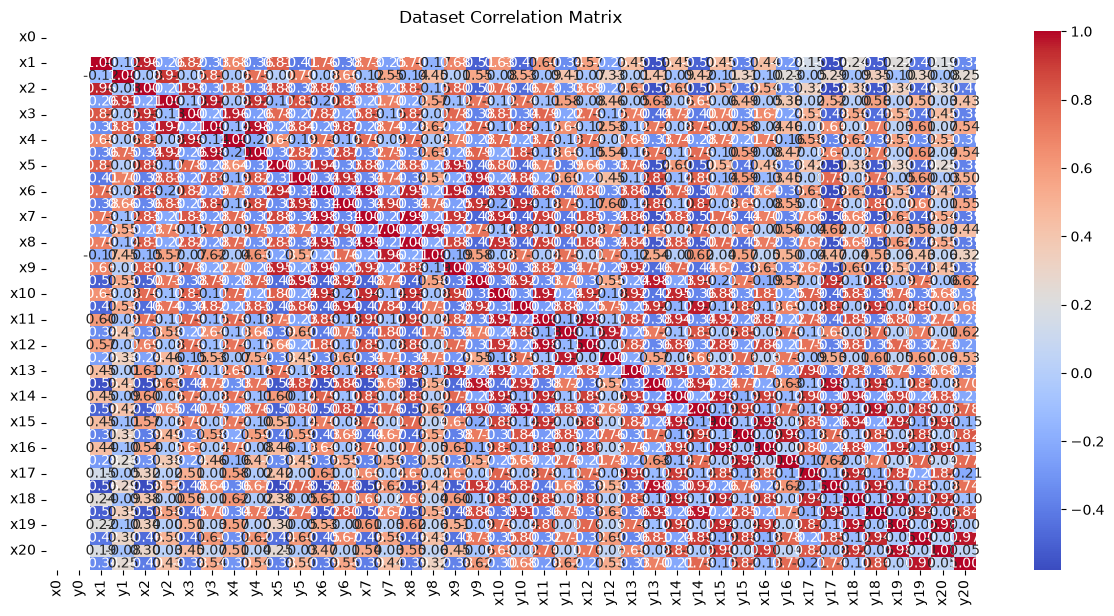

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 7))
#  assume dataset is the DataFrame  

df=pd.read_csv('dataset.csv')
correlation_matrix = df.corr(numeric_only=True) 


sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Dataset Correlation Matrix")
plt.show()

<Figure size 1200x600 with 0 Axes>

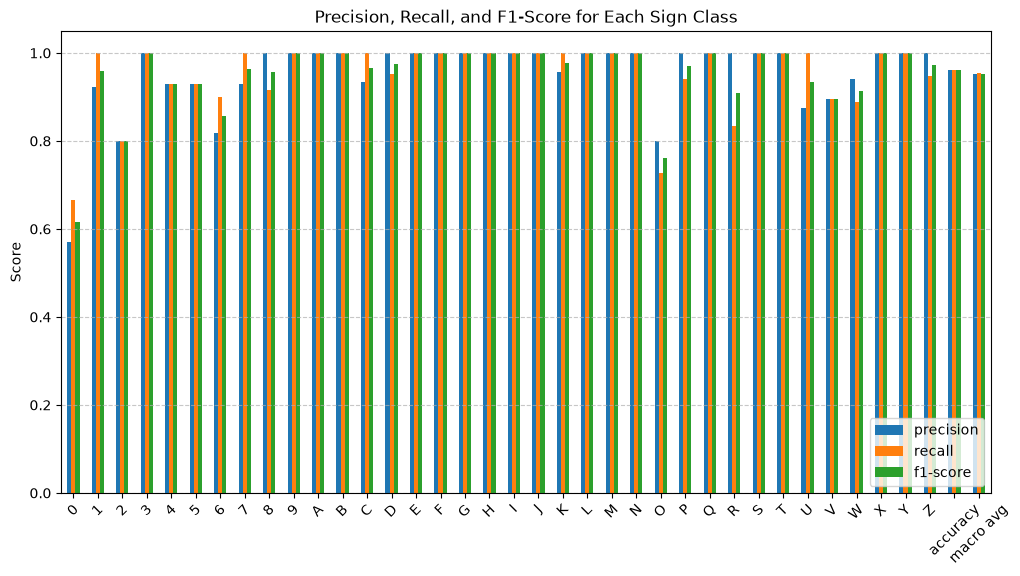

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# extract report clssification as dictionary
report_dict = classification_report(y_test, y_pred, output_dict=True)


report_df = pd.DataFrame(report_dict).iloc[:-1, :-1].T  # Middleton of the classification report

plt.figure(figsize=(12, 6))
report_df.plot(kind='bar', figsize=(12, 6))
plt.title("Precision, Recall, and F1-Score for Each Sign Class")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\LOQ\AppData\Local\Temp\ipykernel_14476\4049156105.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models_names,y=times_values, palette='magma')


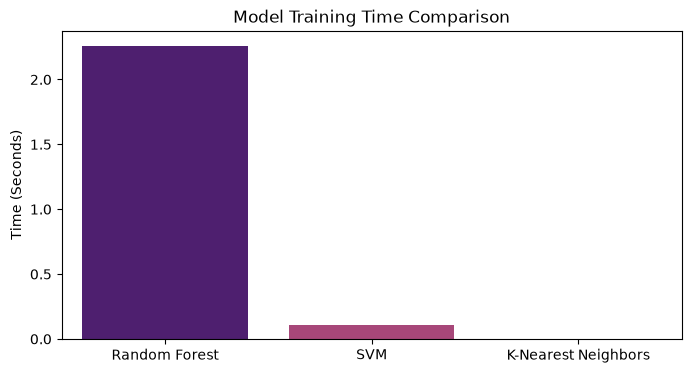

In [ ]:
# calculate training_times  
models_names =list(training_times.keys())

times_values = list(training_times.values())


plt.figure(figsize=(8, 4))
sns.barplot(x=models_names,y=times_values, palette='magma')

plt.title("Model Training Time Comparison")
plt.ylabel("Time (Seconds)")
plt.show()